In [37]:
"""Imports"""
import pickle
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from itertools import combinations
from collections import Counter

In [38]:
"""Constants"""
### pre measurement on 07/18
# TANK_RADIUS_1T_mm = 525.78
# BOTTOM_PADDLE_1_CENTER = (-175, 325, -1228.05)
# BOTTOM_PADDLE_2_CENTER = (-43.18, 185.42, -1228.05)
# BOTTOM_PADDLE_MIDPOINT = tuple((a + b) / 2 for a, b in zip(BOTTOM_PADDLE_1_CENTER, BOTTOM_PADDLE_2_CENTER))
# TOP_PADDLE_CENTER = (86,86,766.5)

### post measurement on 07/18
TANK_RADIUS_1T_mm = 525.78
BOTTOM_PADDLE_1_CENTER = (-31.75, 69.85, -1228.05)
BOTTOM_PADDLE_2_CENTER = (25.4, 177.8, -1228.05)
BOTTOM_PADDLE_MIDPOINT = tuple((a + b) / 2 for a, b in zip(BOTTOM_PADDLE_1_CENTER, BOTTOM_PADDLE_2_CENTER))
TOP_PADDLE_CENTER = (146.05, 139.7, 766.5)
TP_supps_dict = {"adc_b5_ch36": (-180,440), "adc_b5_ch37": (-270,80), "adc_b5_ch38": (-240,-130)}


###
BPs_list = ["lol",BOTTOM_PADDLE_1_CENTER, BOTTOM_PADDLE_2_CENTER]
###

# for reco simulation
TANK_TOP_Z_mm = 666.75
TANK_BOTTOM_Z_mm = -666.75

# HODOSCOPE
hodo_position_map_top = {
    (f"adc_b5_ch{16 - x}", f"adc_b5_ch{y + 1}"): (76 + 20 * x, 38 + 20 * y)
    for x in range(8)
    for y in range(8)
}

hodo_position_map_bottom = {
    (f"adc_b5_ch{32 - x}", f"adc_b5_ch{y + 17}"): (18 + 20 * x, 82 + 20 * y)
    for x in range(8)
    for y in range(8)
}
hodo_position_map = hodo_position_map_top | hodo_position_map_bottom

# some hodos see event way too often
sus_hodos = ['adc_b5_ch31', 'adc_b5_ch26', 'adc_b5_ch32', 'adc_b5_ch29', 'adc_b5_ch30', 'adc_b5_ch25', 'adc_b5_ch24', 'adc_b5_ch27', 'adc_b5_ch28']

In [39]:
"""Functions"""
def find_intersection_with_z(reco_entry_xy, reco_exit_xy, z_entry, z_exit, target_z):
    """
    Extends a vector defined by two points (reco entry and exit) and finds its intersection
    with a given z-plane.

    Parameters:
        reco_entry_xy (tuple): (x, y) coordinates of the reconstructed entry point
        reco_exit_xy (tuple): (x, y) coordinates of the reconstructed exit point
        z_entry (float): z-coordinate of reco entry point (usually TANK_TOP_Z_mm)
        z_exit (float): z-coordinate of reco exit point (usually TANK_BOTTOM_Z_mm)
        target_z (float): the z-plane you want to intersect with (e.g. 766.5 or -1228.05)

    Returns:
        (x, y, target_z): the 3D point where the line intersects the target_z plane
    """
    p0 = np.array([reco_entry_xy[0], reco_entry_xy[1], z_entry], dtype=float)
    p1 = np.array([reco_exit_xy[0], reco_exit_xy[1], z_exit], dtype=float)
    direction = p1 - p0

    if direction[2] == 0:
        raise ValueError("Vector is parallel to the z-plane; no intersection.")

    t = (target_z - p0[2]) / direction[2]
    intersection = p0 + t * direction
    return tuple(intersection)

def load_data(fname):
    with open(fname, "rb") as f:
        data = pickle.load(f)
    return data['reco_events'], data['all_bottom_paddle_tags_for_phase']

def calc_radius(x, y):
    """Simple stuff"""
    return (x**2 + y**2)**0.5

# def get_delta_radius(recos, BP_tags, entry_or_exit: str) -> list[float]:
#     delta_radius_list = []
#     num_events = len(recos)
#     for i in range(num_events):
#         # Get which BP was tagged
#         if BP_tags[i] == 1:
#             BP_loc = BOTTOM_PADDLE_1_CENTER
#         elif BP_tags[i] == 2:
#             BP_loc = BOTTOM_PADDLE_2_CENTER
#         elif BP_tags[i] == 3:
# #             BP_loc = BOTTOM_PADDLE_MIDPOINT
#             continue
# #             print("midpoint!")
# #         if not throughgoing(recos[i]):
# #             continue
#         if entry_or_exit == "entry":
#             reco_x = recos[i]["reco"][0]
#             reco_y = recos[i]["reco"][1]
#             true_x = TOP_PADDLE_CENTER[0]
#             true_y = TOP_PADDLE_CENTER[1]
#         elif entry_or_exit == "exit":
#             reco_x = recos[i]["reco"][2]
#             reco_y = recos[i]["reco"][3]
#             true_x = BP_loc[0]
#             true_y = BP_loc[1]
#         reco_r = calc_radius(reco_x, reco_y)
#         true_r = calc_radius(true_x, true_y)
#         if reco_r > 520: continue # tried to fix big peak at 404
# #         if calc_radius(recos[i]["reco"][0], recos[i]["reco"][1]) > 500: continue
#         delta_radius_list.append(np.abs(reco_r - true_r))
#     return delta_radius_list

def get_distance(recos, BP_tags) -> list[float]:
    """for hodo pmts"""
    exit_distance_list = []
    entry_distance_list = []
    num_events = len(recos)
    list_of_lists = []
    for i in range(num_events):
#         print(BP_tags[i]['hodo'])
        the_hodos = BP_tags[i]['hodo']
#         the_hodos = [item for item in the_hodos if item not in sus_hodos]
        ###
#         list_of_lists.append(BP_tags[i]['hodo'])
        ###
        bottom_truths, top_truths = hodo_pairs(the_hodos)

        entry_reco_x = recos[i]["reco"][0]
        entry_reco_y = recos[i]["reco"][1]

        exit_reco_x = recos[i]["reco"][2]
        exit_reco_y = recos[i]["reco"][3]
        
        # attempted fix by moving this line. therefore, if it's a bad reco on sim tank size,
        # we skip
#         reco_r = calc_radius(reco_x, reco_y)
#         if reco_r > 520:
#             continue # tried to fix big peak at 404
#         print(calc_radius(entry_reco_x, entry_reco_y))
#         if calc_radius(entry_reco_x, entry_reco_y) > 520 or calc_radius(exit_reco_x, exit_reco_y) > 520:
#             continue

        top_intsec = find_intersection_with_z((entry_reco_x, entry_reco_y), (exit_reco_x, exit_reco_y), TANK_TOP_Z_mm, TANK_BOTTOM_Z_mm, TANK_TOP_Z_mm)
        bot_intsec = find_intersection_with_z((entry_reco_x, entry_reco_y), (exit_reco_x, exit_reco_y), TANK_TOP_Z_mm, TANK_BOTTOM_Z_mm, TANK_BOTTOM_Z_mm)

        reco_x_entry, reco_y_entry, reco_z_entry = top_intsec
        reco_x_exit, reco_y_exit, reco_z_exit = bot_intsec

#         reco_r = calc_radius(reco_x, reco_y)
#         true_r = calc_radius(true_x, true_y)
# #         if reco_r > 520:
# #             continue # tried to fix big peak at 404
# #         if np.abs(reco_r - true_r) > 100:
# #             print(reco_x, reco_y)
#         delta_radius_list.append(np.abs(reco_r - true_r))
#         num_hits = recos[i]["total_charge"][1]
        if bottom_truths != []:
            avg_point = tuple(np.mean(bottom_truths, axis=0))
            exit_distance_list.append( np.sqrt((reco_x_exit - avg_point[0])**2 + (reco_y_exit - avg_point[1])**2) )
        if top_truths != []:
            avg_point = tuple(np.mean(top_truths, axis=0))
            entry_distance_list.append( np.sqrt((reco_x_entry - avg_point[0])**2 + (reco_y_entry - avg_point[1])**2) )
#         print(reco_x_entry, reco_y_entry)
    
    # Flatten the list of lists
    all_items = [item for sublist in list_of_lists for item in sublist]

    # Count frequencies
    freq_dict = Counter(all_items)

    # Print the result as a dictionary
    print(dict(freq_dict))

    return entry_distance_list, exit_distance_list

def get_cos_theta(recos) -> list[float]:
    cos_theta_list = []
    num_events = len(recos)
    for i in range(num_events):
        # Get which BP was tagged
        if BP_tags[i] == 1:
#             continue
            BP_loc = BOTTOM_PADDLE_1_CENTER
        elif BP_tags[i] == 2:
            continue
#             BP_loc = BOTTOM_PADDLE_2_CENTER
        elif BP_tags[i] == 3:
            continue
#             BP_loc = BOTTOM_PADDLE_MIDPOINT
#         if not throughgoing(recos[i]):
#             continue
        reco_x_entry = recos[i]["reco"][0]
        reco_y_entry = recos[i]["reco"][1]
        reco_x_exit = recos[i]["reco"][2]
        reco_y_exit = recos[i]["reco"][3]

        true_x_entry = TOP_PADDLE_CENTER[0]
        true_y_entry = TOP_PADDLE_CENTER[1]
        true_z_entry = TOP_PADDLE_CENTER[2]

        true_x_exit = BP_loc[0]
        true_y_exit = BP_loc[1]
        true_z_exit = BP_loc[2]
        

        true_vec = np.array([true_x_exit, true_y_exit, true_z_exit]) - np.array([true_x_entry, true_y_entry, true_z_entry])
        reco_vec = np.array([reco_x_exit, reco_y_exit, TANK_BOTTOM_Z_mm]) - np.array([reco_x_entry, reco_y_entry, TANK_TOP_Z_mm])

        true_normalized = true_vec / np.linalg.norm(true_vec)
        reco_normalized = reco_vec / np.linalg.norm(reco_vec)
        
        dot_product = np.dot(true_normalized, reco_normalized)
        cos_theta_list.append(dot_product)
#         if dot_product < 0:
#             print(reco_x_entry, reco_y_entry, true_x_entry, true_y_entry, reco_x_exit, reco_y_exit, true_x_exit, true_y_exit)
    return cos_theta_list

def majority_trigger(event) -> bool:
    """Index into the 26th hit. If it is one of the 28 bottom PMTs, we know
    this is a majority trigger event."""
    pmt_num = event["hits"][25][4]
    if pmt_num <= 28:
        return True
    return False

def throughgoing(event) -> bool:
    """Returns a bool if reco points are within top and bottom bases of 
    cylindrical detector, because this implies they did not enter/exit side"""
    reco_x_entry = event["reco"][0]
    reco_y_entry = event["reco"][1]
    reco_x_exit = event["reco"][2]
    reco_y_exit = event["reco"][3]
    if (calc_radius(reco_x_entry, reco_y_entry) < TANK_RADIUS_1T_mm) and (calc_radius(reco_x_exit, reco_y_exit) < TANK_RADIUS_1T_mm):
        return True
    return False

def hodo_pairs(hodo_hit_list):
    
    # Create a mapping from frozenset to original ordered key
    unordered_to_ordered = {frozenset(k): k for k in hodo_position_map_bottom}
    valid_pairs_with_positions = []

    for ch1, ch2 in combinations(hodo_hit_list, 2):
        unordered = frozenset([ch1, ch2])
        if unordered in unordered_to_ordered:
            ordered_pair = unordered_to_ordered[unordered]
            position = hodo_position_map_bottom[ordered_pair]
            valid_pairs_with_positions.append((ordered_pair, position))

    # Output
    bottom_hodos = []
    for pair, pos in valid_pairs_with_positions:
        bottom_hodos.append(pos)
#         print(f"Channels {pair} map to position {pos}")   
    
    # again for top
    unordered_to_ordered = {frozenset(k): k for k in hodo_position_map_top}
    valid_pairs_with_positions = []

    for ch1, ch2 in combinations(hodo_hit_list, 2):
        unordered = frozenset([ch1, ch2])
        if unordered in unordered_to_ordered:
            ordered_pair = unordered_to_ordered[unordered]
            position = hodo_position_map_top[ordered_pair]
            valid_pairs_with_positions.append((ordered_pair, position))

    # Output
    top_hodos = []
    for pair, pos in valid_pairs_with_positions:
        top_hodos.append(pos)
    
    return bottom_hodos, top_hodos

def get_distance_TP(recos, BP_tags) -> list[float]:
    """for TP supps, only entry here"""
    entry_distance_list = []
    num_events = len(recos)
    for i in range(num_events):
        TP_supp_hits = BP_tags[i]['TP_supp']
        if len(TP_supp_hits) > 1: continue
        
        if recos[i]['total_charge'][0] > 1000: continue
        
        
        true_x, true_y = TP_supps_dict[TP_supp_hits[0]]

        entry_reco_x = recos[i]["reco"][0]
        entry_reco_y = recos[i]["reco"][1]
        exit_reco_x = recos[i]["reco"][2]
        exit_reco_y = recos[i]["reco"][3]
        
        # attempted fix by moving this line. therefore, if it's a bad reco on sim tank size,
        # we skip
#         reco_r = calc_radius(reco_x, reco_y)
#         if reco_r > 520:
#             continue # tried to fix big peak at 404
#         print(calc_radius(entry_reco_x, entry_reco_y))
#         if calc_radius(entry_reco_x, entry_reco_y) > 520 or calc_radius(exit_reco_x, exit_reco_y) > 520:
#             continue

        top_intsec = find_intersection_with_z((entry_reco_x, entry_reco_y), (exit_reco_x, exit_reco_y), TANK_TOP_Z_mm, TANK_BOTTOM_Z_mm, TANK_TOP_Z_mm)

        reco_x_entry, reco_y_entry, reco_z_entry = top_intsec

#         reco_r = calc_radius(reco_x, reco_y)
#         true_r = calc_radius(true_x, true_y)
# #         if reco_r > 520:
# #             continue # tried to fix big peak at 404
# #         if np.abs(reco_r - true_r) > 100:
# #             print(reco_x, reco_y)
#         delta_radius_list.append(np.abs(reco_r - true_r))
#         num_hits = recos[i]["total_charge"][1]
        entry_distance_list.append( np.sqrt((reco_x_entry - true_x)**2 + (reco_y_entry - true_y)**2) )
#         print(reco_x_entry, reco_y_entry)
    return entry_distance_list

In [40]:
user_file_choice = 5

##### water
### eloss files
elosstank_digit_weight_all = "/storage/group/dfc13/default/dcolson/BNL/data/infile_data4/recos/elosstank_digit_weight_all/07_29_25_disk_d_phase_3_weight_wBP_reco_elosstank_digit_weight_all.pkl"
elosstank_digit_edge_all = "/storage/group/dfc13/default/dcolson/BNL/data/infile_data4/recos/elosstank_digit_edge_all/07_29_25_disk_d_phase_3_cfd_wBP_reco_elosstank_digit_edge_all.pkl"
elosstank_digit_weight_per = "/storage/group/dfc13/default/dcolson/BNL/data/infile_data4/recos/elosstank_digit_weight_per/07_29_25_disk_d_phase_3_weight_wBP_reco_elosstank_digit_weight_per.pkl"
elosstank_digit_edge_per = "/storage/group/dfc13/default/dcolson/BNL/data/infile_data4/recos/elosstank_digit_edge_per/07_29_25_disk_d_phase_3_cfd_wBP_reco_elosstank_digit_edge_per.pkl"

### numCher files
numCher_digit_edge_all = "/storage/group/dfc13/default/dcolson/BNL/data/infile_data4/recos/numCher_digit_edge_all/07_29_25_disk_d_phase_3_cfd_wBP_reco_numCher_digit_edge_all.pkl"
numCher_digit_edge_per = "/storage/group/dfc13/default/dcolson/BNL/data/infile_data4/recos/numCher_digit_edge_per/07_23_25_disk_d_phase_3_cfd_1_reco_numCher_digit_edge_per.pkl"
numCher_digit_weight_all = "/storage/group/dfc13/default/dcolson/BNL/data/infile_data4/recos/numCher_digit_weight_all/07_29_25_disk_d_phase_3_weight_wBP_reco_numCher_digit_weight_all.pkl"
numCher_digit_weight_per = "/storage/group/dfc13/default/dcolson/BNL/data/infile_data4/recos/numCher_digit_weight_per/07_29_25_disk_d_phase_3_weight_wBP_reco_numCher_digit_weight_per.pkl"

water_file_list = [
    elosstank_digit_weight_all,  #0
    elosstank_digit_edge_all,    #1
    elosstank_digit_weight_per,  #2
    elosstank_digit_edge_per,    #3
    numCher_digit_edge_all,      #4
    numCher_digit_edge_per,      #5
    numCher_digit_weight_all,    #6
    numCher_digit_weight_per     #7
]
##### wbls
### only edge, weighted got messed up
wbls_elosstank_digit_edge_all = "/storage/group/dfc13/default/dcolson/wbls_sim/recos/elosstank_digit_edge_all/07_16_25_disk_l_phase_9_cfd_1_reco_elosstank_digit_edge_all.pkl"
wbls_elosstank_digit_edge_per = "/storage/group/dfc13/default/dcolson/wbls_sim/recos/elosstank_digit_edge_per/07_16_25_disk_l_phase_9_cfd_1_reco_elosstank_digit_edge_per.pkl"
wbls_numCher_digit_edge_all = "/storage/group/dfc13/default/dcolson/wbls_sim/recos/numCher_digit_edge_all/07_16_25_disk_l_phase_9_cfd_1_reco_numCher_digit_edge_all.pkl"
wbls_numCher_digit_edge_per = "/storage/group/dfc13/default/dcolson/wbls_sim/recos/numCher_digit_edge_per/07_16_25_disk_l_phase_9_cfd_1_reco_numCher_digit_edge_per.pkl"

wbls_file_list = [
    wbls_elosstank_digit_edge_all, #0
    wbls_elosstank_digit_edge_per, #1
    wbls_numCher_digit_edge_all,   #2
    wbls_numCher_digit_edge_per    #3
]

real_file = water_file_list[user_file_choice]
###
reco_events, BP_tags = load_data(real_file)
# reco_type = real_file.split("/")[8]
reco_type = real_file.split("/")[10]
hist_tag = str(reco_type)
print("total number of recos", len(reco_events))
print(hist_tag)
# print(reco_events[0]['total_charge']) # proof im not crazy
print(len(BP_tags))
# for i in BP_tags:
#     print(hodo_pairs(i['hodo']), "\n")


total number of recos 1973
numCher_digit_edge_per
1973


{}
{}


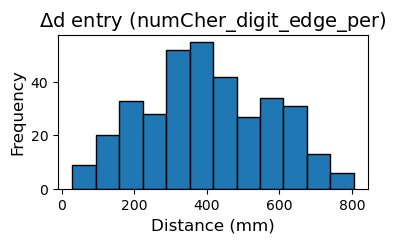

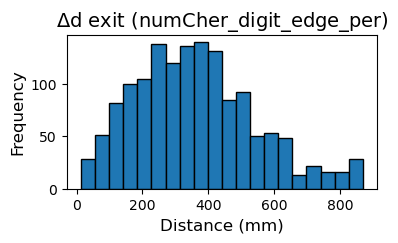

In [41]:
values = get_distance(reco_events, BP_tags)[0]
# print(values)
# print("len values", len(values))
# print("68th percentile", np.percentile(values, 68), "mm")
# Create the entry histogram
plt.figure(figsize=(4, 2))
plt.hist(values, bins="auto", edgecolor='black')

# Add labels and title (optional)
plt.xlabel('Distance (mm)', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.title(fr'$\Delta$d entry (numCher_digit_edge_per)', fontsize=14)

# Show the plot
# plt.show()
plt.savefig(f"/storage/group/dfc13/default/dcolson/poster_plots/water_hodo_entry.png", dpi=300, bbox_inches="tight")

values = get_distance(reco_events, BP_tags)[1]
# print(values)
# print("len values", len(values))
# print("68th percentile", np.percentile(values, 68), "mm")
# Create the entry histogram
plt.figure(figsize=(4, 2))
plt.hist(values, bins="auto", edgecolor='black')

# Add labels and title (optional)
plt.xlabel('Distance (mm)', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.title(fr'$\Delta$d exit (numCher_digit_edge_per)', fontsize=14)

# Show the plot
# plt.show()
plt.savefig(f"/storage/group/dfc13/default/dcolson/poster_plots/water_hodo_exit.png", dpi=300, bbox_inches="tight")

In [42]:
values = get_distance_TP(reco_events, BP_tags)
print("68th percentile", np.percentile(values, 68), "mm")
plt.figure(figsize=(4, 2))
plt.hist(values, bins="auto", edgecolor='black')

# Add labels and title (optional)
plt.xlabel('Distance (mm)', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
# plt.title(f'Distance between reco entry and additional TP center, {hist_tag}')

plt.title(fr'$\Delta$d entry ({hist_tag})', fontsize=14)

# Show the plot
# plt.show()
plt.savefig(f"/storage/group/dfc13/default/dcolson/poster_plots/delta_d_TP345_{hist_tag}.png", dpi=300, bbox_inches="tight")

# Show the plot
# plt.show()

ValueError: The truth value of an array with more than one element is ambiguous. Use a.any() or a.all()